# SMAP Pixel Land-Use Composition
This notebook computes land-use classes inside a SMAP pixel and reports area percentage by class.

In [1]:
# Install if needed: pip install geopandas pandas matplotlib pyproj
from pathlib import Path
import warnings

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

In [2]:
# Update these paths to your files
smap_pixel_shape = Path(r"C:\SoilGrids\zhurucay\SMAP_pixel_zhurucay.shp")
landuse_path = Path(r"C:\SoilGrids\cobertura_vegetal\Cobertura_vegetal_ECUADOR_2022_100k_UTM_WGS84_17S.shp")

# Optional: where to save output CSV
output_csv = Path(r"c:\Bachelorarbeit\resultados\smap_pixel_landuse_percentages.csv")

print('SMAP pixel:', smap_pixel_shape)
print('Land use :', landuse_path)
print('CSV out  :', output_csv)

SMAP pixel: C:\SoilGrids\zhurucay\SMAP_pixel_zhurucay.shp
Land use : C:\SoilGrids\cobertura_vegetal\Cobertura_vegetal_ECUADOR_2022_100k_UTM_WGS84_17S.shp
CSV out  : c:\Bachelorarbeit\resultados\smap_pixel_landuse_percentages.csv


In [3]:
# Read shapefiles
smap = gpd.read_file(smap_pixel_shape)
landuse = gpd.read_file(landuse_path)

print('SMAP features   :', len(smap))
print('Land-use features:', len(landuse))
print('SMAP CRS   :', smap.crs)
print('Land-use CRS:', landuse.crs)

SMAP features   : 1
Land-use features: 279077
SMAP CRS   : EPSG:4326
Land-use CRS: EPSG:32717


In [4]:
# Choose a projected CRS to compute area in square meters
# Prefer UTM 17S (EPSG:32717) given your data description.
target_crs = 'EPSG:32717'

if smap.crs is None or landuse.crs is None:
    raise ValueError('One or both layers have no CRS defined. Define CRS before analysis.')

smap_proj = smap.to_crs(target_crs)
landuse_proj = landuse.to_crs(target_crs)

# Dissolve SMAP to a single polygon in case it contains multiple parts
smap_union = smap_proj.dissolve()
smap_union = smap_union[['geometry']].copy()

# Clip land use to SMAP extent for performance
landuse_clip = gpd.clip(landuse_proj, smap_union)

print('Land-use features intersecting SMAP:', len(landuse_clip))

Land-use features intersecting SMAP: 21


In [10]:
# Identify land-use attribute column
print('Land-use columns:')
print(list(landuse_clip.columns))

# Use the confirmed land-use class field
landuse_col = 'ctn2'
if landuse_col not in landuse_clip.columns:
    raise ValueError(f"Expected land-use column '{landuse_col}' not found. Available: {list(landuse_clip.columns)}")

print('Using land-use category column:', landuse_col)

Land-use columns:
['objectid', 'fcode', 'ctn1', 'ctn2', 'anio', 'are', 'vuln_score', 'geometry']
Using land-use category column: ctn2


In [11]:
# Intersect and calculate area per land-use class
intersections = gpd.overlay(
    landuse_clip[[landuse_col, 'geometry']].copy(),
    smap_union[['geometry']].copy(),
    how='intersection'
)

if intersections.empty:
    raise ValueError('No overlap found between SMAP pixel and land-use polygons.')

intersections['area_m2'] = intersections.geometry.area
total_area_m2 = intersections['area_m2'].sum()

summary = (
    intersections.groupby(landuse_col, dropna=False)['area_m2']
    .sum()
    .reset_index()
    .sort_values('area_m2', ascending=False)
)
summary['pct_of_smap'] = 100.0 * summary['area_m2'] / total_area_m2
summary['area_ha'] = summary['area_m2'] / 10000.0

# Reorder columns
summary = summary[[landuse_col, 'area_m2', 'area_ha', 'pct_of_smap']]

# Nice formatting copy for display
summary_display = summary.copy()
summary_display['area_m2'] = summary_display['area_m2'].round(2)
summary_display['area_ha'] = summary_display['area_ha'].round(4)
summary_display['pct_of_smap'] = summary_display['pct_of_smap'].round(2)

print(f'Total intersected area: {total_area_m2:,.2f} m2')
summary_display

Total intersected area: 111,330,021.95 m2


,ctn2,area_m2,area_ha,pct_of_smap
3,PARAMO,1.093899e+08,10938.9872,98.26
4,PASTIZAL,9.054000e+05,90.5400,0.81
1,CUERPO DE AGUA NATURAL,5.240650e+05,52.4065,0.47
5,PLANTACION FORESTAL,2.730854e+05,27.3085,0.25
2,INFRAESTRUCTURA,2.313000e+05,23.1300,0.21
0,BOSQUE NATIVO,6.300000e+03,0.6300,0.01


In [12]:
# Save results
output_csv.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(output_csv, index=False)
print('Saved:', output_csv)

Saved: c:\Bachelorarbeit\resultados\smap_pixel_landuse_percentages.csv


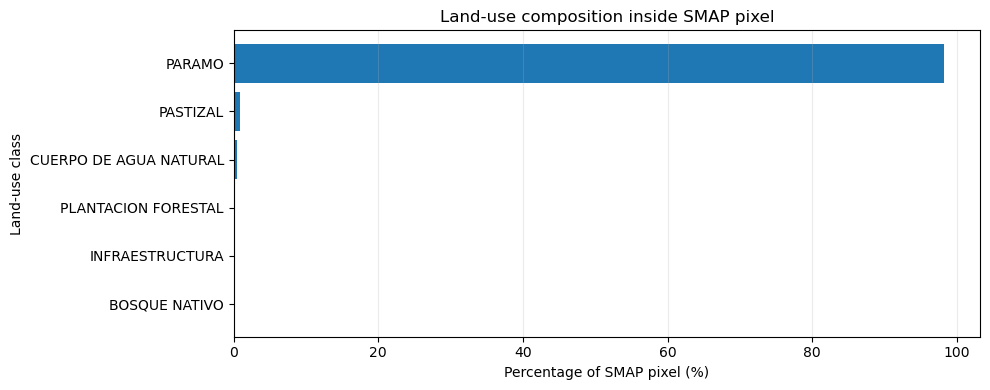

In [13]:
# Plot percentage composition
plot_df = summary_display.sort_values('pct_of_smap', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))
ax.barh(plot_df[landuse_col].astype(str), plot_df['pct_of_smap'])
ax.set_xlabel('Percentage of SMAP pixel (%)')
ax.set_ylabel('Land-use class')
ax.set_title('Land-use composition inside SMAP pixel')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

NDVI distribution summary:
count    1.121481e+06
mean     4.827477e-01
std      1.123773e-01
min     -6.111111e-01
5%       3.202323e-01
25%      4.038826e-01
50%      4.720598e-01
75%      5.584872e-01
95%      6.775035e-01
max      8.768752e-01
Name: NDVI, dtype: float64

Point NDVI (TIFF at coord): 0.4643
Percentile within SMAP pixel distribution: 47.22%


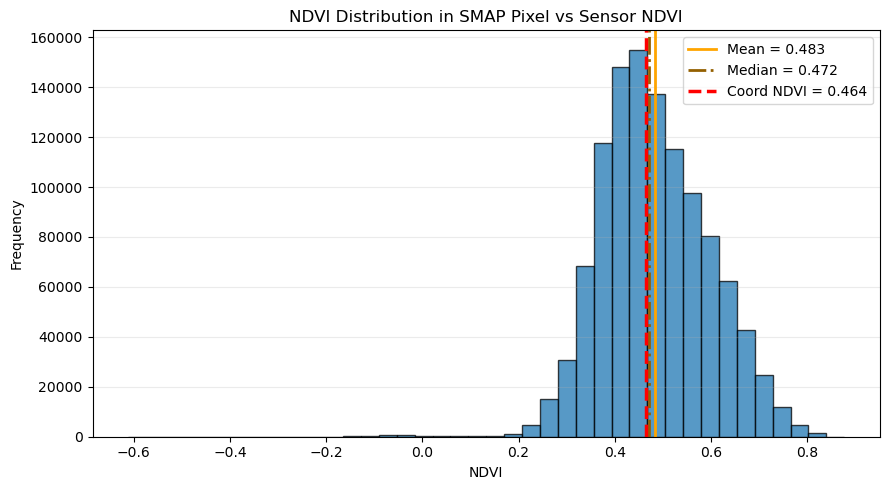

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inputs
coord_lon, coord_lat = -79.234636, -3.062424
csv_path = Path(r"C:\Soilgrids\data\smap\SMAP_NDVI_distribution_AugNov_2022.csv")
tif_path = Path(r"C:\Soilgrids\data\smap\SMAP_NDVI_composite_AugNov_2022.tif")

# Optional fallback if you already know point NDVI from another source
manual_point_ndvi = None  # e.g., 0.76

if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found: {csv_path}")

# Read NDVI distribution
df = pd.read_csv(csv_path)
if "NDVI" not in df.columns:
    raise ValueError(f"Column 'NDVI' not found. Available columns: {list(df.columns)}")

ndvi = pd.to_numeric(df["NDVI"], errors="coerce").dropna()
if ndvi.empty:
    raise ValueError("No valid NDVI values found in CSV.")

# Try to get point NDVI directly from raster at the coordinate
point_ndvi = None
point_source = None

if tif_path.exists():
    try:
        import rasterio
        from pyproj import Transformer

        with rasterio.open(tif_path) as src:
            # Transform lon/lat (EPSG:4326) to raster CRS when needed
            x, y = coord_lon, coord_lat
            if src.crs is not None and str(src.crs).upper() not in ["EPSG:4326", "OGC:CRS84"]:
                transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
                x, y = transformer.transform(coord_lon, coord_lat)

            row, col = src.index(x, y)
            arr = src.read(1)
            val = arr[row, col]

            if src.nodata is not None and np.isclose(val, src.nodata):
                point_ndvi = np.nan
            else:
                point_ndvi = float(val)
                # Scale integer NDVI products if needed (common scale factor 10000)
                if point_ndvi > 1.0:
                    point_ndvi = point_ndvi / 10000.0
                point_source = "TIFF at coord"
    except Exception as e:
        print(f"Could not extract NDVI from TIFF: {e}")

# Fallback to manual value if raster extraction is unavailable
if point_ndvi is None and manual_point_ndvi is not None:
    point_ndvi = float(manual_point_ndvi)
    point_source = "manual"

# Summary stats and percentile
desc = ndvi.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print("NDVI distribution summary:")
print(desc)

if point_ndvi is not None and not np.isnan(point_ndvi):
    percentile = (ndvi <= point_ndvi).mean() * 100
    print(f"\nPoint NDVI ({point_source}): {point_ndvi:.4f}")
    print(f"Percentile within SMAP pixel distribution: {percentile:.2f}%")
else:
    print("\nPoint NDVI not available. Set manual_point_ndvi or verify TIFF path/CRS.")

# Plot histogram + point marker
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ndvi, bins=40, alpha=0.75, edgecolor="black")
ax.axvline(ndvi.mean(), linestyle="-", linewidth=2, color="orange", label=f"Mean = {ndvi.mean():.3f}")
ax.axvline(ndvi.median(), linestyle="-.", linewidth=2, color="#946001", label=f"Median = {ndvi.median():.3f}")


ax.axvline(point_ndvi, linestyle="--", linewidth=2.5, color="red", label=f"Coord NDVI = {point_ndvi:.3f}")

ax.set_xlabel("NDVI")
ax.set_ylabel("Frequency")
ax.set_title("NDVI Distribution in SMAP Pixel vs Sensor NDVI")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()